In [67]:
import os
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
import matplotlib.pyplot as plt

OUTPUT_PATH = "ad_hoc_instruments.csv"
INFERENCE_CSV = "./ner-inference_findings.csv"

entries = [
    {
        "title": "Beijing Declaration and Platform for Action",
        "location": "Beijing",
        "year": 2015
    },
    {
        "title": "Agreement on Identity and Rights of Indigenous Peoples",
        "location": "Mexico City",
        "year": 1995,
        "id": "S/1995/256",
        "institution": "Security Council",
        "url": "https://peacemaker.un.org/sites/default/files/document/files/2024/05/gt950331agreementidentityandrightsofindigenouspeoples.pdf"
    },
    {
        "title": "Statute of the United Nations Special Fund for Land-locked Developing Countries",
        "location": "",
        "year": 1977,
        "id": "A/RES/31/177",
        "institution": "General Assembly",
        "url": "https://digitallibrary.un.org/record/199677?v=pdf"
    }
]

if os.path.exists(OUTPUT_PATH):
    ad_hoc_instruments = pd.read_csv(OUTPUT_PATH)

    # Keep only the requested columns
    ad_hoc_instruments = ad_hoc_instruments[["title", "location", "year"]]

    # Add the new entries
    ad_hoc_instruments = pd.concat(
        [ad_hoc_instruments, pd.DataFrame(entries)],
        ignore_index=True
    )
else:
    ad_hoc_instruments = pd.DataFrame(entries)

# Remove duplicate entries
ad_hoc_instruments = ad_hoc_instruments.drop_duplicates(
    subset=["title", "location", "year"]
).reset_index(drop=True)

#ad_hoc_instruments.to_csv(file_path, index=False)

found_instruments = pd.read_csv(INFERENCE_CSV)

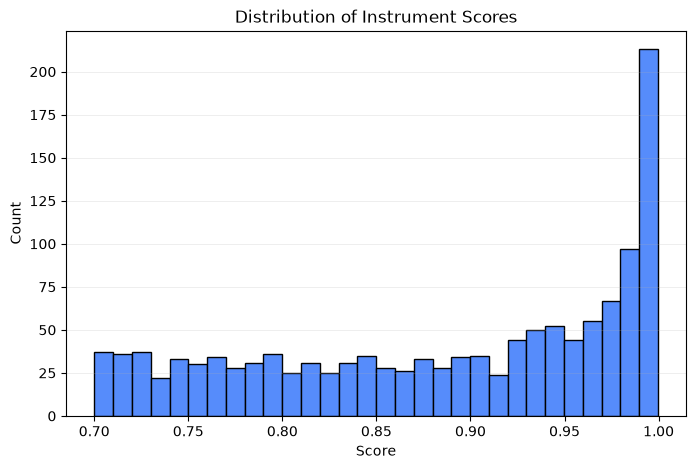

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(found_instruments["score"].dropna(), bins=30, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Distribution of Instrument Scores")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [69]:
filtered = (
    found_instruments[found_instruments["score"] > 0.75]
    .sort_values("score", ascending=False)
    .drop_duplicates(subset="text", keep="first")
)
print(f"{len(filtered)} unique titles")

filtered[["text", "score"]].head()

535 unique titles


,text,score
65,charter of the united nations,0.999667
745,convention on the declaration of death of missing persons,0.999479
1172,international convention on the elimination of all forms of religious intolerance,0.999460
268,convention on privileges and immunities of the united nations,0.999453
642,convention on the elimination of discrimination against women,0.999451


In [70]:
df_res = pd.read_csv("../resolutions/ga_resolutions_1946_2019.csv")
df_res.rename(columns={"res_id2": "id"}, inplace=True)

cols = ["title", "year", "alternative_name"]

df_wiki = pd.read_csv("../treaties/wiki-treaties_formatted.csv")
df_wiki = df_wiki.rename(
    columns={"name": "title", "cleaned_note": "alternative_name"}
)[cols]

df_ohchr = pd.read_csv("../ohchr_instruments/ohchr_instruments_detailed-instit.csv")
df_ohchr["year"] = pd.to_datetime(
    df_ohchr["adoption_date"], format="%d %B %Y"
).dt.year
df_ohchr["alternative_name"] = ""
df_ohchr = df_ohchr[cols]

df_uno = pd.read_csv("../treaties/UNO-Treaties.csv")
df_uno["year"] = pd.to_datetime(
    df_uno["date"], format="%d %B %Y"
).dt.year
df_uno["alternative_name"] = ""
df_uno = df_uno[cols]

df_unesco = pd.read_csv("../unesco_instruments/UNESCO_legal_instruments_detail.csv")
df_unesco["year"] = pd.to_datetime(
    df_unesco["date"], format="%d %B %Y"
).dt.year
df_unesco["alternative_name"] = ""
df_unesco = df_unesco.rename(columns={"name": "title"})[cols]

df_conv_prot_rec = pd.read_csv(
"../conv-prot-rec/conventions-protocols-recommendations.csv"
)
df_conv_prot_rec["alternative_name"] = ""
df_conv_prot_rec = df_conv_prot_rec[cols]

df_instrument = pd.concat(
    [df_wiki, df_ohchr, df_uno, df_unesco, df_conv_prot_rec],
    ignore_index=True
)
df_instrument = df_instrument.drop_duplicates()

In [73]:
import re, unicodedata

def normalize(text):
    if pd.isna(text):
        return ""
    text = unicodedata.normalize("NFKD", text)
    text = text.lower().strip()
    text = re.sub(r"[’‘`´]", "'", text)     # curly quotes -> straight
    text = re.sub(r"[“”]", '"', text)
    text = re.sub(r"[–—―]", "-", text)       # en/em dash -> hyphen
    text = re.sub(r"\s+", " ", text)         # collapse whitespace
    return text

found_instruments["text_norm"] = found_instruments["text"].apply(normalize)
df_instrument["title_norm"] = df_instrument["title"].apply(normalize)

already_present = found_instruments["text_norm"].isin(df_instrument["title_norm"])
new_instruments = found_instruments[~already_present].copy()


In [76]:
new_instruments = (new_instruments
                   .sort_values("score", ascending=False)
                   .drop_duplicates(subset="text", keep="first")
)
new_instruments

,id,text,score,start,end,label,text_norm
1172,2020 (xx),international convention on the elimination of all forms of religious intolerance,0.999460,96,177,TREATY,international convention on the elimination of all forms of religious intolerance
268,239 c (iii),convention on privileges and immunities of the united nations,0.999453,319,380,TREATY,convention on privileges and immunities of the united nations
642,33/177,convention on the elimination of discrimination against women,0.999451,203,264,TREATY,convention on the elimination of discrimination against women
773,58 (i),charter of united nations,0.999432,173,198,TREATY,charter of united nations
506,2295 (xxii),international convention on the elimination of all forms of intolerance and of discrimination based on religion or belief,0.999413,310,431,TREATY,international convention on the elimination of all forms of intolerance and of discrimination based on religion or belief
758,34/183,international convention for the prevention of pollution of the sea by oil,0.999409,2271,2345,TREATY,international convention for the prevention of pollution of the sea by oil
102,37/169,declaration on the human rights of individuals who are not citizens of the country in which they live,0.999373,954,1055,TREATY,declaration on the human rights of individuals who are not citizens of the country in which they live
63,1680 (xvi),"convention on consent to marriage, minimum age of marriage and registration of marriages",0.999365,422,510,TREATY,"convention on consent to marriage, minimum age of marriage and registration of marriages"
1171,2020 (xx),declaration on the elimination of all forms of religious intolerance,0.999356,17,85,TREATY,declaration on the elimination of all forms of religious intolerance
1177,47/45,"convention on the prohibition of the development, production and stock-piling of bacteriological (biological) and toxin weapons and on their destruction",0.999302,1897,2049,TREATY,"convention on the prohibition of the development, production and stock-piling of bacteriological (biological) and toxin weapons and on their destruction"


In [86]:
from spacy.matcher import PhraseMatcher
import spacy

nlp = spacy.load("en_core_web_sm")

# the offending titles (already established to be in both sets)
offenders = (
    found_instruments[found_instruments["text_norm"].isin(df_instrument["title_norm"])]
    .drop_duplicates(subset="text_norm")
)

rows = []
for _, r in offenders.iterrows():
    doc_id = r["id"]                                 # <-- adjust to your actual link column
    content_match = df_res.loc[df_res["id"] == doc_id, "content"]
    if content_match.empty:
        continue
    content = content_match.iloc[0]

    # 1. plain substring search — no tokenization involved at all
    raw_hit = r["text"].lower() in content.lower()

    # 2. rebuild a single-alias PhraseMatcher and run it on this exact doc
    m = PhraseMatcher(nlp.vocab, attr="LOWER")
    m.add("CHECK", [nlp.make_doc(r["text"])])
    phrase_hit = len(m(nlp(content))) > 0

    rows.append({
        "doc_id": doc_id,
        "text": r["text"],
        "raw_substring_found": raw_hit,
        "phrasematcher_found": phrase_hit,
    })

diag = pd.DataFrame(rows)
missed_by_matcher = diag[diag["raw_substring_found"] & ~diag["phrasematcher_found"]]
missed_by_matcher

,doc_id,text,raw_substring_found,phrasematcher_found
1,68/247 b,convention on the rights of persons with disabilities,True,False
2,54/68,"treaty on principles governing the activities of states in the exploration and use of outer space, including the moon and other celestial bodies",True,False
3,51/45 c,comprehensive nuclear-test-ban treaty,True,False
4,45/58 c,charter of the united nations,True,False
5,52/211 a,convention relating to the status of refugees,True,False
6,52/211 a,convention on the elimination of all forms of discrimination against women,True,False
7,57/229,standard rules on the equalization of opportunities for persons with disabilities,True,False
8,52/157,convention on the recognition and enforcement of foreign arbitral awards,True,False
9,52/38 b,treaty on the non-proliferation of nuclear weapons,True,False
10,59/27,united nations millennium declaration,True,False
